In [1]:
%reload_ext autoreload
%autoreload 2

import os
import sys

import numpy as np
import jax

sys.path.append("..")
from utils.multi_corner import multi_corner
from utils.validation import find_hdi_prob, roc_finite_sample_band
from models.validate_models import RandomModel, PoissonModel

os.environ["XLA_FLAGS"] = "--xla_gpu_force_compilation_parallelism=1"
print(jax.devices())

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cms
mpl.rc_file("../notebooks/matplotlibrc")

/n/home07/yitians/.conda/envs/torch/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[gpu(id=0)]


## HMC

In [11]:
# config poisson
rng_key = jax.random.PRNGKey(42)

n_run = 30
model = PoissonModel()
n_temp = len(model.temps)
prefix = 'pm'
use_neutra = True

test = True
p_runs = []
rng_key, key = jax.random.split(rng_key)
truth_arr = jax.random.normal(key, shape=(n_temp,)) * 0.5 + 3
truth_dict = {f'temp_{i}' : t for i, t in enumerate(truth_arr)}
model.set_truth(truth_arr)

for i_run in range(n_run if not test else 1):
    print(f'{i_run}:')
    rng_key, key = jax.random.split(rng_key)
    counts = model.generate_counts(key)
    rng_key, key = jax.random.split(rng_key)
    model.fit_svi(key, guide='iaf', num_flows=5, hidden_dims=[128, 128],
                  n_steps=2500, lr=5e-5, num_particles=8, counts=counts)
    rng_key, key = jax.random.split(rng_key)
    mcmc = model.run_nuts(
        num_chains=4, num_warmup=500, num_samples=20000, step_size=0.01,
        rng_key=key, use_neutra=True, counts=counts
    )
    rng_key, key = jax.random.split(rng_key)
    samples = mcmc.get_samples()
    p = []
    for i in range(n_temp):
        s = np.array(samples[f'temp_{i}'])
        m = truth_arr[i]
        p.append(find_hdi_prob(s, m, level=15))
    p_runs.append(p)
p_runs = np.array(p_runs).T
p_runs = np.sort(p_runs, axis=1)
if not test:
    np.save(f"{prefix}_ntemp{n_temp}_nrun{n_run}.npy", p_runs)

0:


sample: 100%|██████████| 20500/20500 [03:30<00:00, 97.42it/s] 


In [12]:
# use_neutra = True
mcmc.print_summary()


                            mean       std    median      5.0%     95.0%     n_eff     r_hat
 auto_shared_latent[0]     -0.01      2.29     -0.20     -3.52      3.27    817.22      1.01
 auto_shared_latent[1]     -0.52      2.27     -0.52     -3.88      2.98    697.63      1.01
 auto_shared_latent[2]     -1.36      2.95     -1.48     -5.88      3.76    750.53      1.01
 auto_shared_latent[3]     -1.12      2.64     -0.74     -5.30      2.84    706.47      1.01
 auto_shared_latent[4]     -1.25      2.36     -0.92     -4.47      2.26    716.00      1.00
 auto_shared_latent[5]     -1.60      3.77     -0.98     -6.93      3.88    738.47      1.01
 auto_shared_latent[6]     -0.99      3.03     -1.13     -5.69      3.77    926.36      1.00
 auto_shared_latent[7]      1.92      6.21      0.88     -6.79     10.77    487.99      1.01
 auto_shared_latent[8]      1.85      3.50      1.64     -3.42      7.63   1094.36      1.00
 auto_shared_latent[9]     -0.66      1.89     -0.43     -3.69      2

In [ ]:
# use_neutra = False
mcmc.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
    temp_0      2.61      0.03      2.61      2.57      2.66    773.84      1.01
    temp_1      4.24      0.45      4.26      3.51      4.98    111.95      1.02
   temp_10      2.14      0.13      2.13      1.92      2.35    187.00      1.01
    temp_2      2.80      0.12      2.80      2.61      3.01    228.34      1.01
    temp_3      3.34      0.93      3.36      1.89      4.94     73.61      1.03
    temp_4      2.06      0.69      2.06      0.90      3.17    255.83      1.03
    temp_5      3.23      1.18      3.21      1.37      5.17     88.06      1.02
    temp_6      3.18      0.93      3.20      1.68      4.79     86.80      1.05
    temp_7      3.53      2.07      3.45      0.02      6.37     87.04      1.03
    temp_8      3.93      1.08      3.92      2.14      5.65    109.69      1.02
    temp_9      2.34      1.09      2.29      0.34      3.91    139.31      1.02

Number of divergences: 0


## SVI

In [ ]:
# config random
rng_key = jax.random.PRNGKey(42)

n_temp = 30
n_run = 30
rng_key, key = jax.random.split(rng_key)
model = RandomModel(key, 6400, n_temp)
prefix = 'rm'

In [ ]:
# config poisson
rng_key = jax.random.PRNGKey(42)

n_run = 30
model = PoissonModel()
n_temp = len(model.temps)
prefix = 'pm'

0:


100%|██████████| 2500/2500 [00:07<00:00, 314.15it/s, init loss: 132000.0312, avg. loss [2376-2500]: 23252.7871] 


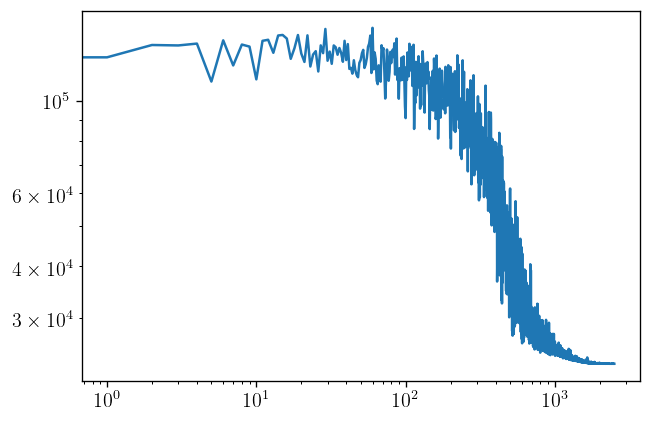

In [32]:
test = True
p_runs = []
rng_key, key = jax.random.split(rng_key)
truth_arr = jax.random.normal(key, shape=(n_temp,)) * 0.5 + 3
truth_dict = {f'temp_{i}' : t for i, t in enumerate(truth_arr)}
model.set_truth(truth_arr)

for i_run in range(n_run if not test else 1):
    print(f'{i_run}:')
    rng_key, key = jax.random.split(rng_key)
    counts = model.generate_counts(key)
    rng_key, key = jax.random.split(rng_key)
    model.fit_svi(key, guide='iaf', num_flows=5, hidden_dims=[128, 128],
                  n_steps=2500, lr=5e-5, num_particles=8, counts=counts)
    rng_key, key = jax.random.split(rng_key)
    samples = model.get_svi_samples(50000, key)
    p = []
    for i in range(n_temp):
        s = np.array(samples[f'temp_{i}'])
        m = truth_arr[i]
        p.append(find_hdi_prob(s, m, level=15))
    p_runs.append(p)
p_runs = np.array(p_runs).T
#p_runs = np.sort(p_runs, axis=1)
if not test:
    np.save(f"{prefix}_ntemp{n_temp}_nrun{n_run}.npy", p_runs)
if test:
    plt.plot(model.svi_results.losses)
    plt.loglog()

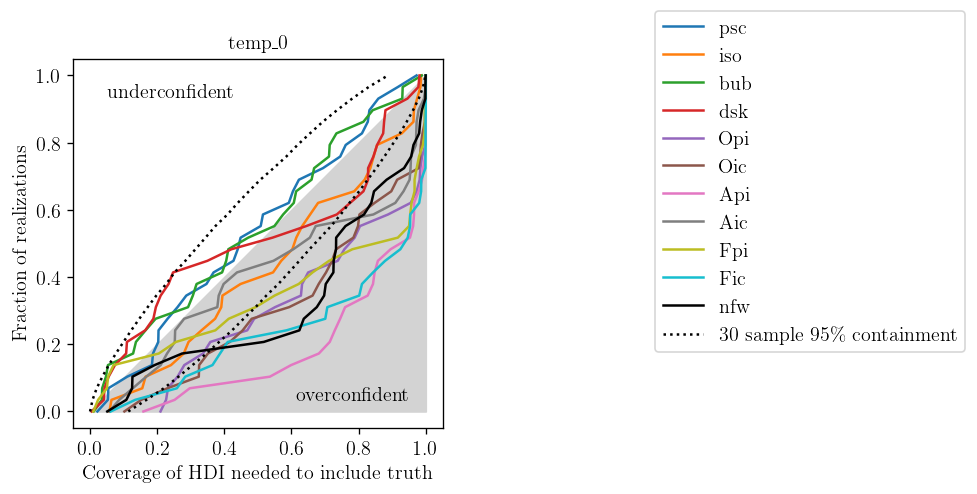

In [14]:
invcdf_lower, invcdf_upper = roc_finite_sample_band(n_run)

fig, ax = plt.subplots()

ax.fill_between([0,1], [0,1], color='lightgray')
for i, p in enumerate(p_runs):
    color = f'C{i}'
    if model.labels[i] == 'nfw':
        color = 'k'
    ax.plot(p, np.linspace(0, 1, n_run), color=color, label=model.labels[i])

ax.plot(invcdf_upper, np.linspace(0, 1, n_run), 'k:', label=f'{n_run} sample 95\% containment')
ax.plot(invcdf_lower, np.linspace(0, 1, n_run), 'k:')

ax.set(aspect=1)
ax.set(xlabel='Coverage of HDI needed to include truth', ylabel='Fraction of realizations',
       title=f'{k}')
ax.text(0.95, 0.05, 'overconfident', ha='right', va='center')
ax.text(0.05, 0.95, 'underconfident', ha='left', va='center')

fig.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

In [ ]:
invcdf_lower, invcdf_upper = roc_finite_sample_band(n_run)
k = 'temp_0'

fig, ax = plt.subplots()

ax.fill_between([0,1], [0,1], color='lightgray')
for p in p_runs:
    ax.plot(p, np.linspace(0, 1, n_run), color='k', label=k)

ax.plot(invcdf_upper, np.linspace(0, 1, n_run), 'k:', label=f'{n_run} sample 95\% containment')
ax.plot(invcdf_lower, np.linspace(0, 1, n_run), 'k:')

ax.set(aspect=1)
ax.set(xlabel='Coverage of HDI needed to include truth', ylabel='Fraction of realizations',
       title=f'{k}')
ax.text(0.95, 0.05, 'overconfident', ha='right', va='center')
ax.text(0.05, 0.95, 'underconfident', ha='left', va='center');

## View

In [17]:
samples_plot = {k : s for k, s in samples.items() if k.startswith('temp_')}

In [19]:
model.labels

['psc', 'iso', 'bub', 'dsk', 'Opi', 'Oic', 'Api', 'Aic', 'Fpi', 'Fic', 'nfw']

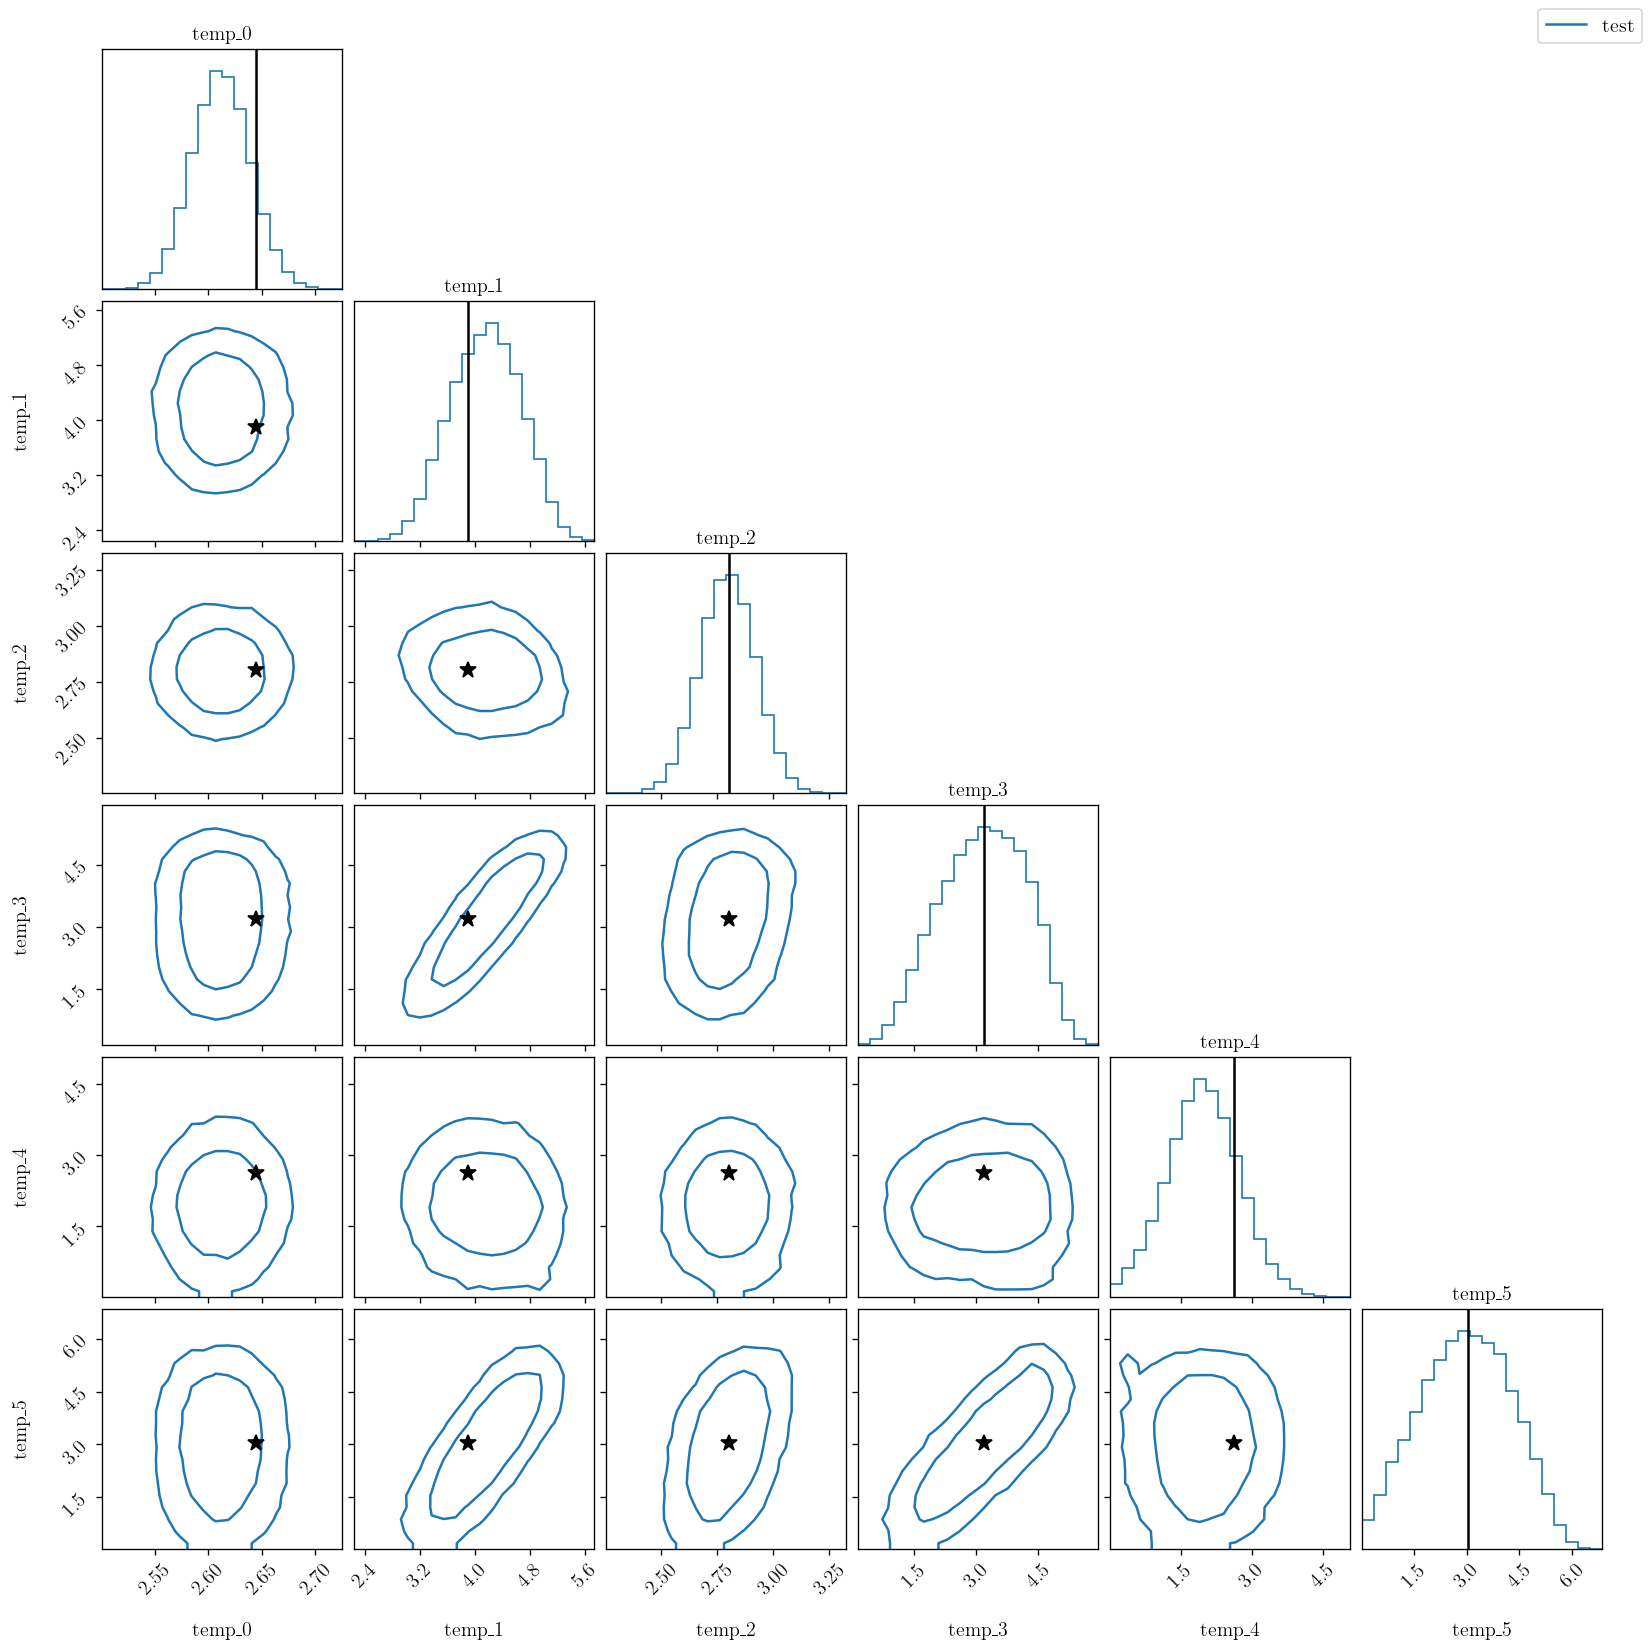

In [18]:
samples_dict = {'' : samples_plot}
colors_dict = {'' : 'C0'}
labels_dict = {'' : 'test'}
plot_var_names = ['temp_0', 'temp_1', 'temp_2', 'temp_3', 'temp_4', 'temp_5']
truth_dict = {f'temp_{i}' : t for i, t in enumerate(truth_arr)}
multi_corner(
    samples_dict, plot_var_names, MAP=truth_dict,
    colors_dict=colors_dict, labels_dict=labels_dict,
    hist_bin_factor=1
)